<a href="https://colab.research.google.com/github/Anushriya3007/ANUSHRIYA-R_4NI23CI018_ML2LAB_E1/blob/main/MLLAB2KMEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Dataset shape:
(150, 4)


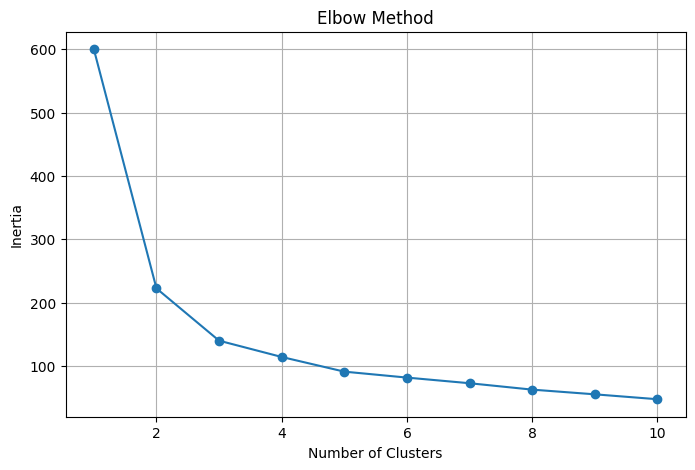


Clustered Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  
5        1  
6        1  
7     

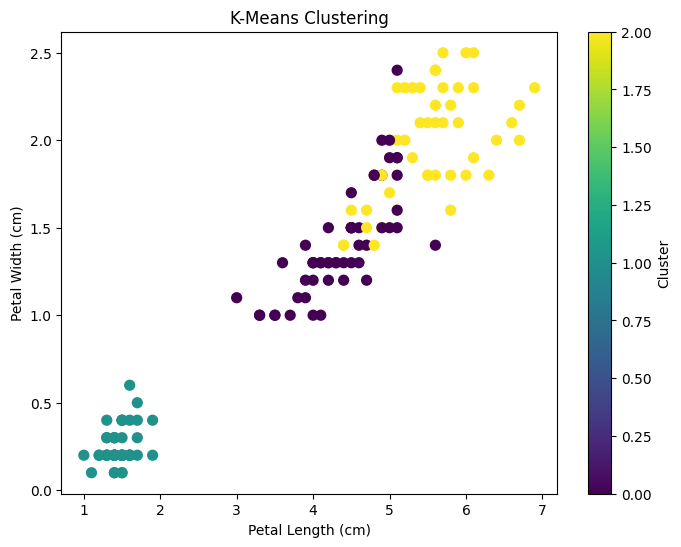

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Display dataset
print("First 5 rows:")
print(X.head())

print("\nDataset shape:")
print(X.shape)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

# K-Means with 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
X["Cluster"] = clusters

print("\nClustered Dataset:")
print(X.head(10))

# Silhouette Score
score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", score)

# Cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=iris.feature_names
)

print("\nCluster Centers:")
print(centers_df)

# Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    X["petal length (cm)"],
    X["petal width (cm)"],
    c=X["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("K-Means Clustering")
plt.colorbar(label="Cluster")
plt.show()
